# AI Financial Fraud Detection System

## Business Understanding

Financial fraud has become a major challenge for banks and digital payment platforms due to the rapid growth of online transactions. Fraudulent transactions cause significant financial losses, reduce customer trust, and increase operational costs.

The objective of this project is to develop a machine learning-based fraud detection system that can accurately classify transactions as genuine or fraudulent using historical transaction data. The project also aims to analyze transaction patterns, evaluate multiple machine learning models, and identify the most effective model for fraud detection.

In [57]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
path="/content/drive/MyDrive/AI-Financial-Fraud-Detection/Data/Raw/creditcard.csv"

df=pd.read_csv(path)

In [60]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Dataset Overview

## Objective

Understand the basic structure, size, and characteristics of the dataset before performing detailed analysis.

In [61]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 284807
Columns : 31


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [64]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [65]:
df.duplicated().sum()

np.int64(1081)

In [66]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [67]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


# Data Understanding Summary

### Observation

- The dataset contains **284,807** transactions and **31** columns.
- There are **no missing values** in the dataset.
- The dataset contains **1,081 duplicate records**.
- The target variable (`Class`) has two categories:
  - **0** → Genuine Transaction
  - **1** → Fraudulent Transaction
- Fraudulent transactions make up only **0.17%** of the dataset, while genuine transactions account for **99.83%**.
- This indicates that the dataset is **highly imbalanced**.

# Exploratory Data Analysis (EDA)

### Objective

Explore the dataset to understand transaction patterns, identify relationships between features, and compare genuine and fraudulent transactions.

## 1. Class Distribution

### Objective

Understand the distribution of genuine and fraudulent transactions in the dataset.

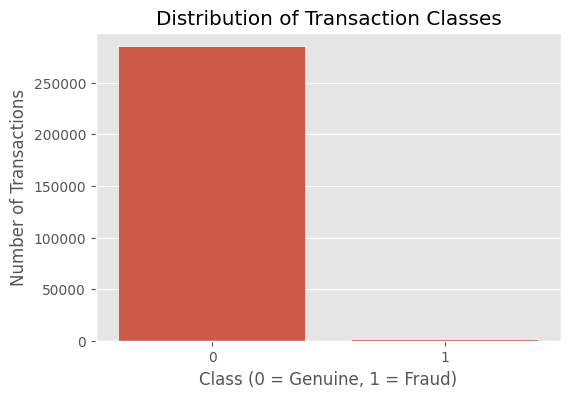

In [68]:
# Count plot of transaction classes
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [69]:
# Percentage distribution
class_percentage = (df["Class"].value_counts(normalize=True) * 100).round(2)

class_percentage

,proportion
Class,
0,99.83
1,0.17


### Observation

- Genuine transactions account for approximately **99.83%** of the dataset.
- Fraudulent transactions account for approximately **0.17%** of the dataset.
- The dataset is highly imbalanced.

### Business Insight

A machine learning model trained directly on this dataset may become biased toward genuine transactions. Therefore, techniques for handling class imbalance should be considered during preprocessing.

## 2. Correlation Heatmap

### Objective

Analyze the correlation between different features in the dataset.

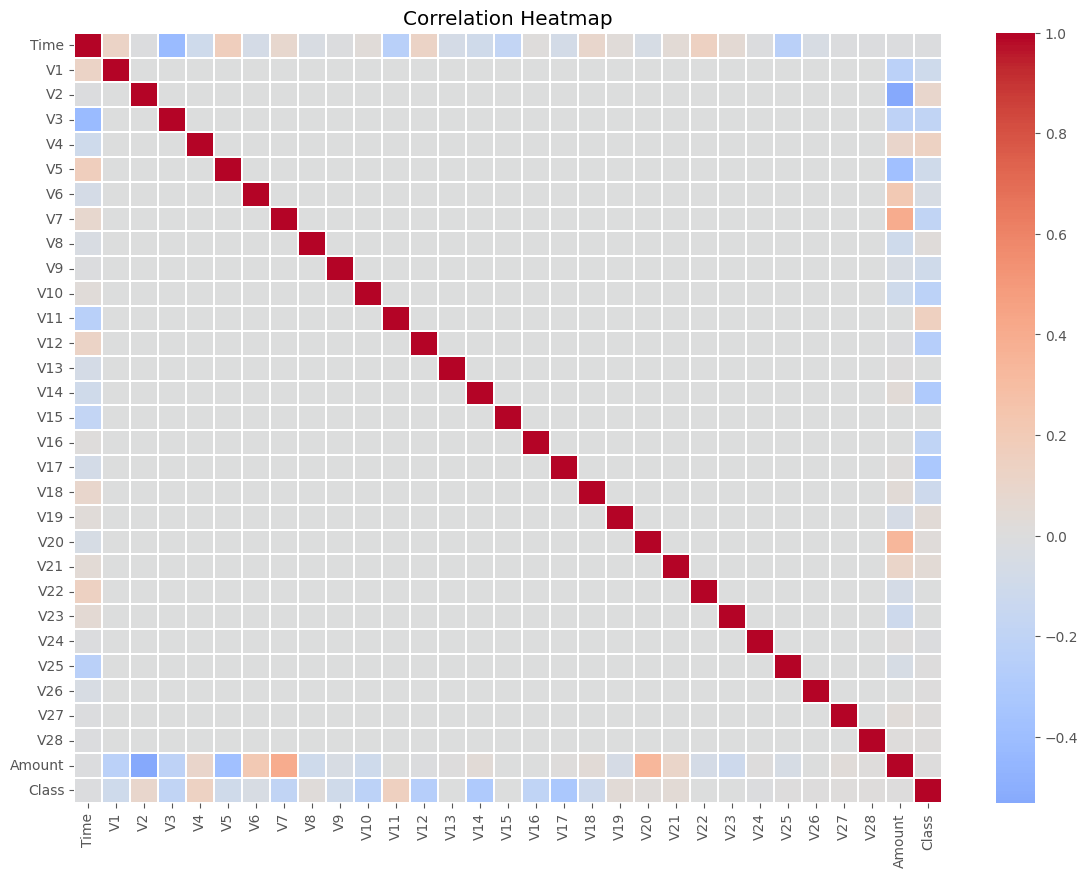

In [70]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

- Most features show very weak correlation with each other.
- Only a few feature pairs have moderate positive or negative correlation.
- The target variable (`Class`) has weak linear correlation with most features.

### Business Insight

Since most features are not strongly correlated, they provide different information about each transaction. This can help machine learning models learn better patterns for fraud detection.

## 3. Feature Correlation with Target

### Objective

Identify the features that have the strongest positive or negative correlation with fraudulent transactions.

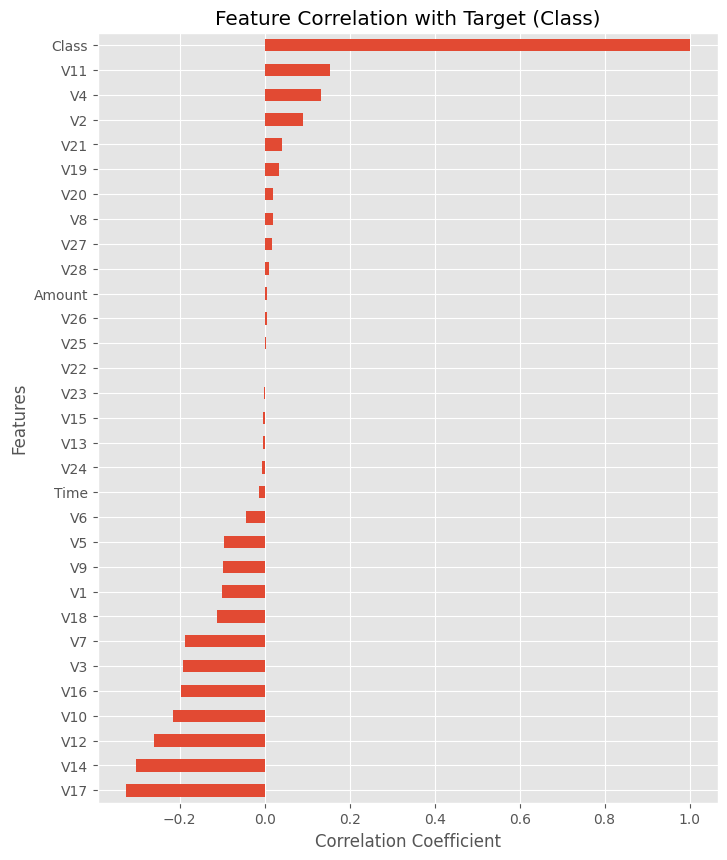

In [71]:
# Correlation of all features with the target variable
correlation = df.corr()["Class"].sort_values()

plt.figure(figsize=(8, 10))

correlation.plot(kind="barh")

plt.title("Feature Correlation with Target (Class)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

### Observation

- Most features have weak correlation with the target variable.
- A few features show relatively stronger positive or negative correlation with fraud.
- Features with higher absolute correlation may be more useful for fraud detection.

### Business Insight

Features that are more strongly correlated with fraudulent transactions can help machine learning models distinguish fraud from genuine transactions more effectively.

## 4. Transaction Amount by Class

### Objective

Compare the transaction amount for genuine and fraudulent transactions.

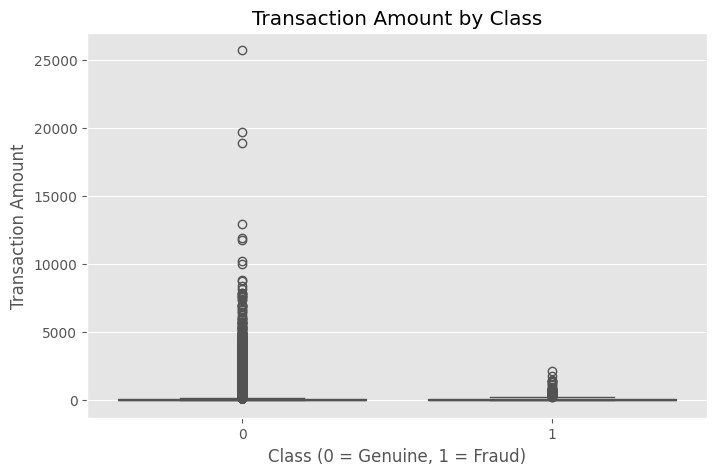

In [72]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

### Observation

- Most transactions have relatively small amounts.
- The transaction amount varies widely for genuine transactions.
- Fraudulent transactions also occur across different transaction amounts, with some extreme values present.

### Business Insight

Transaction amount alone is not sufficient to identify fraud. It should be combined with other transaction features to improve fraud detection performance.

## 5. Transaction Time by Class

### Objective

Compare when genuine and fraudulent transactions occurred during the recorded time period.

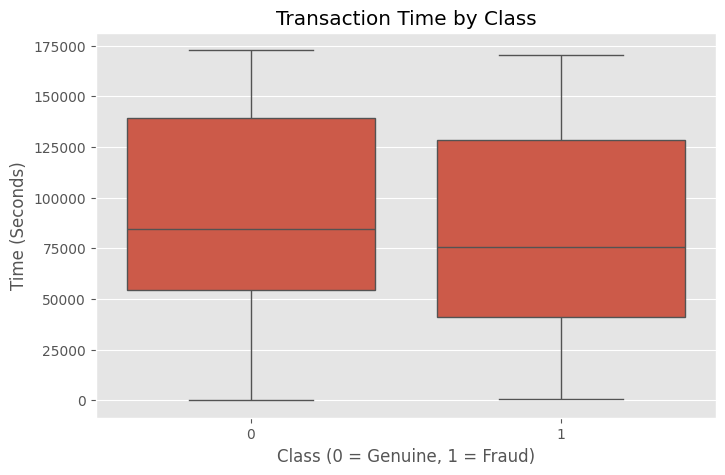

In [73]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Time")

plt.title("Transaction Time by Class")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Time (Seconds)")

plt.show()

### Observation

- Genuine and fraudulent transactions occur throughout the recorded time period.
- There is significant overlap between the two classes.
- No clear separation between genuine and fraudulent transactions is visible based only on time.

### Business Insight

Transaction time alone is not a strong indicator of fraud. It becomes more useful when combined with other transaction features during model training.

## 6. Distribution of Transaction Amount

### Objective

Understand how transaction amounts are distributed across the dataset.

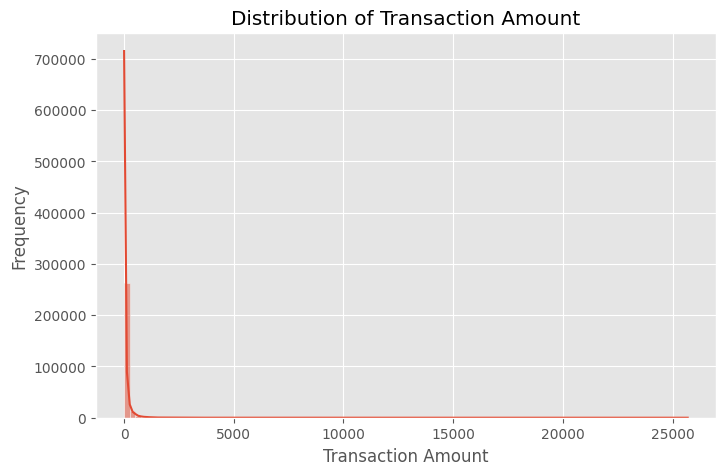

In [74]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=100, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most transactions involve small amounts.
- The distribution is highly right-skewed.
- A few transactions have very large amounts, indicating the presence of outliers.

### Business Insight

Since transaction amounts vary over a wide range, feature scaling will be useful before training machine learning models.

# EDA Conclusion

### Summary

The exploratory data analysis provided several important insights into the dataset:

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of the data.
- Most features show weak linear correlation with each other and with the target variable.
- Transaction amount is highly right-skewed and contains several outliers.
- Genuine and fraudulent transactions overlap in terms of transaction time and amount, indicating that no single feature can reliably identify fraud.
- These findings highlight the importance of proper preprocessing and using machine learning models capable of learning complex patterns from multiple features.